In [21]:
from ultralytics import YOLO

model = YOLO("yolo8m.pt")

model.train(
    data="./fall_dataset/data.yaml",
    epochs=500,
    patience=50,
    imgsz=640,
    save=True,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.50 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.48  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./fall_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=500, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000025A29CDE090>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

In [22]:
model.save("yolo-fall-3.pt")

In [12]:
metrics = model.val()

Ultralytics 8.4.48  Python-3.11.9 torch-2.11.0+cpu CPU (Intel Core Ultra 7 255H)
val: Fast image access  (ping: 0.10.0 ms, read: 212.569.4 MB/s, size: 37.8 KB)
val: Scanning C:\Project\Python_Source\AI01\mini_project_07\fall\valid\labels.cache... 101 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 101/101  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.2it/s 5.7s1.0ss
                   all        101        107      0.808       0.76      0.769      0.505
         Fall Detected         63         63      0.875      0.794      0.827      0.543
       NoFall Detected         42         44      0.742      0.727      0.711      0.467
Speed: 0.8ms preprocess, 48.4ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Project\Python_Source\AI01\runs\detect\val-3


In [13]:
metrics.box.map

np.float64(0.505053411919903)

In [14]:
metrics.box.map50

np.float64(0.769255675750272)

In [15]:
metrics.box.map75

np.float64(0.6099881225949702)

In [16]:
metrics.box.image_metrics

{'fall006_jpg.rf.020085d592ae4f3821307e54c06c51b8.jpg': {'precision': 0.5,
  'recall': 1.0,
  'f1': 0.6666666666666666,
  'tp': 1,
  'fp': 1,
  'fn': 0},
 'fall009_jpg.rf.9476f233fa3b9566ff922b73655d03a4.jpg': {'precision': 0.25,
  'recall': 1.0,
  'f1': 0.4,
  'tp': 1,
  'fp': 3,
  'fn': 0},
 'fall011_jpg.rf.edd2602465274435dcb4fe484cbd2c5a.jpg': {'precision': 0.5,
  'recall': 1.0,
  'f1': 0.6666666666666666,
  'tp': 1,
  'fp': 1,
  'fn': 0},
 'fall015_jpg.rf.15ad16dc45963b184dbc472cfa0f4021.jpg': {'precision': 0.25,
  'recall': 1.0,
  'f1': 0.4,
  'tp': 1,
  'fp': 3,
  'fn': 0},
 'fall021_jpg.rf.94eb8b11f41666c6d3372d495cdd7293.jpg': {'precision': 0.09090909090909091,
  'recall': 1.0,
  'f1': 0.16666666666666669,
  'tp': 1,
  'fp': 10,
  'fn': 0},
 'fall025_jpg.rf.8b34aa5fcb770c1af7361d3f02121bea.jpg': {'precision': 0.3333333333333333,
  'recall': 1.0,
  'f1': 0.5,
  'tp': 1,
  'fp': 2,
  'fn': 0},
 'fall030_jpg.rf.2464a8168a5e85f727cd77a8cb295868.jpg': {'precision': 0.0,
  'recall':

In [26]:
import cv2
from ultralytics import YOLO
import numpy as np

def detect_objects():
    # 동영상, 모델 로드
    VideoSignal = cv2.VideoCapture('02673_H_A_SY_C3.mp4')
    detect_model = YOLO("../runs/detect/train-6/weights/best.pt")

    fource = cv2.VideoWriter_fourcc(*'XVID')
    record = False
    i = 0

    while True:
        # 파일에서 한 프레임 읽음
        ret, frame = VideoSignal.read()
        

        if not ret:
            print("끝")
            break

        frame = cv2.resize(frame, (640, 480))
        

        # 모델을 통해 객체 탐지
        results = detect_model(frame, stream=True, verbose=False, conf=0.6)

        for result in results:
            boxes = result.boxes
            for box in boxes:
                # 사각형의 좌상단, 우하단 좌표
                x1, y1, x2, y2 = map(int, box.xyxy[0])
    
                # 탐지된 사물의 확신도
                conf = float(box.conf[0])
                # 탐지된 사물의 클래스 번호
                cls_id = int(box.cls[0])
                # 탐지된 사물의 이름
                class_name = result.names[cls_id]

                if cls_id == 0 and record == False:
                    video = cv2.VideoWriter(f"fall_{i}.avi", fource, 20.0, (frame.shape[1], frame.shape[0]))
                    record = True
                    cnt = 90
                    
                # 이미지 위에 사각형 박스 그림
                cv2.rectangle(frame, (x1, y1), (x2, y2), (255,255,255), 2)
    
                # 표시할 이름과 점수
                label = f"{class_name} {conf:.3f}"
                cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_ITALIC,0.5, (255,255,255), 2)

        if record == True:
            print("녹화 중..")
            # 현재 프레임을 영상파일에 저장
            video.write(frame)
            cnt-=1
            if cnt == 0:
                record = False
                video.release()
                print("저장")
                i+=1

        cv2.imshow("YOLO26", frame)

        if cv2.waitKey(1) != -1:
            break

    VideoSignal.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    detect_objects()

녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
저장
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 중..
녹화 

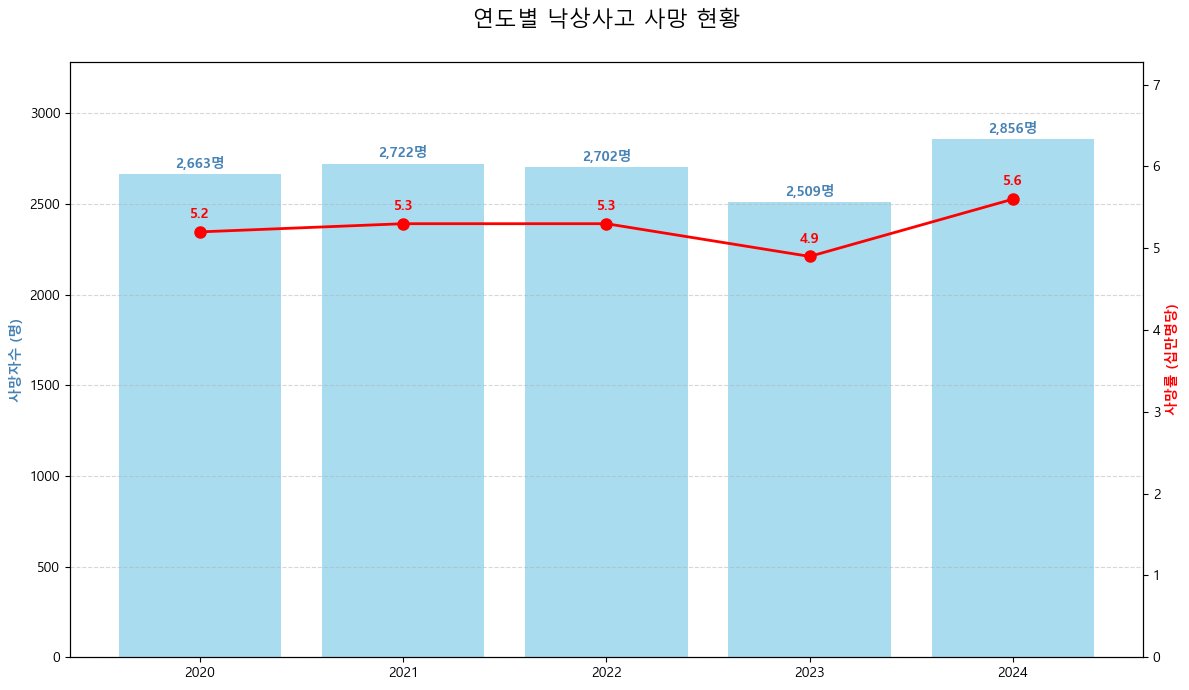

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 읽기
df = pd.read_csv('낙상_사망_계.csv', header=[0, 1], index_col=0, encoding='cp949')
total_data = df.loc['계']

years = ['2020', '2021', '2022', '2023', '2024']
deaths = [total_data[(year, '사망자수 (명)')] for year in years]
rates = [total_data[(year, '사망률 (십만명당)')] for year in years]

# 2. 그래프 생성
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax1 = plt.subplots(figsize=(12, 7))

# 막대 그래프 (사망자수)
bars = ax1.bar(years, deaths, color='skyblue', alpha=0.7, label='사망자수 (명)')
ax1.set_ylabel('사망자수 (명)', color='steelblue', fontweight='bold')
ax1.set_ylim(0, max(deaths) * 1.15)

# --- 막대 위에 숫자 추가 ---
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{int(height):,}명', ha='center', va='bottom', color='steelblue', fontweight='bold')

# 꺾은선 그래프 (사망률)
ax2 = ax1.twinx()
line = ax2.plot(years, rates, color='red', marker='o', markersize=8, linewidth=2, label='사망률 (십만명당)')
ax2.set_ylabel('사망률 (십만명당)', color='red', fontweight='bold')
ax2.set_ylim(0, max(rates) * 1.3)

# --- 꺾은선 위에 숫자 추가 ---
for i, rate in enumerate(rates):
    ax2.annotate(f'{rate}', (years[i], rates[i]),
                 textcoords="offset points", xytext=(0, 10),
                 ha='center', color='red', fontweight='bold')

# 마무리
plt.title('연도별 낙상사고 사망 현황', fontsize=16, pad=25)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

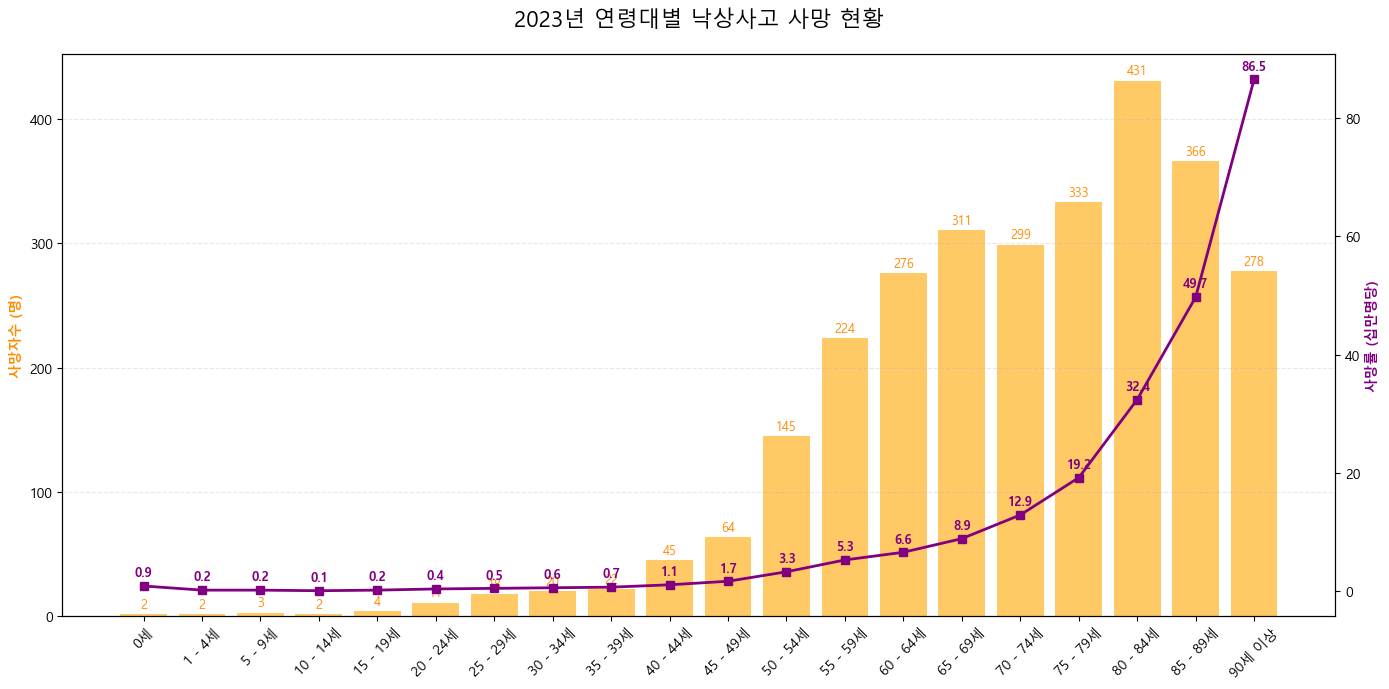

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 읽기
df = pd.read_csv('낙상_사망_계.csv', header=[0, 1], index_col=0, encoding='cp949')

# 2. '계' 행을 제외한 연령대 데이터만 추출
# '계' 행과 '15세 미만', '65세 이상' 등 중복 집계 항목 제외 (순수 연령별 구간만 선택)
age_groups = ['0세', '1 - 4세', '5 - 9세', '10 - 14세', '15 - 19세', '20 - 24세', 
              '25 - 29세', '30 - 34세', '35 - 39세', '40 - 44세', '45 - 49세', 
              '50 - 54세', '55 - 59세', '60 - 64세', '65 - 69세', '70 - 74세', 
              '75 - 79세', '80 - 84세', '85 - 89세', '90세 이상']

target_year = '2023'
df_age = df.loc[age_groups]

age_deaths = df_age[(target_year, '사망자수 (명)')]
age_rates = df_age[(target_year, '사망률 (십만명당)')]

# 3. 그래프 그리기
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax1 = plt.subplots(figsize=(14, 7))

# 막대 그래프 (사망자수)
bars = ax1.bar(age_groups, age_deaths, color='orange', alpha=0.6, label='사망자수 (명)')
ax1.set_ylabel('사망자수 (명)', color='darkorange', fontweight='bold')
ax1.tick_params(axis='x', rotation=45) # 연령대 텍스트 겹침 방지

# 꺾은선 그래프 (사망률)
ax2 = ax1.twinx()
ax2.plot(age_groups, age_rates, color='purple', marker='s', linewidth=2, label='사망률 (십만명당)')
ax2.set_ylabel('사망률 (십만명당)', color='purple', fontweight='bold')

# 숫자 추가
for i, (d, r) in enumerate(zip(age_deaths, age_rates)):
    
    ax1.text(i, d + 5, f'{int(d)}', ha='center', color='darkorange', fontsize=9)
    
    ax2.annotate(f'{r}', (i, r), xytext=(0, 7), textcoords='offset points', 
                 ha='center', color='purple', fontsize=9, fontweight='bold')

plt.title('2023년 연령대별 낙상사고 사망 현황', fontsize=16, pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()

In [2]:
import torch
print(f"설치된 버전: {torch.__version__}")

설치된 버전: 2.12.0.dev20260408+cu128


In [29]:
detect_model = YOLO("../runs/detect/train-6/weights/best.pt")
metrics = detect_model.val()

Ultralytics 8.4.48  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 268.1198.5 MB/s, size: 84.2 KB)
val: Scanning C:\Project\Python_Source\AI01\mini_project_07\fall_dataset\val\labels.cache... 111 images, 0 backgrounds, 19 corrupt: 100% ━━━━━━━━━━━━ 111/111  0.0s
val: C:\Project\Python_Source\AI01\mini_project_07\fall_dataset\val\images\fall049.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 2. Possible class labels are 0-1
val: C:\Project\Python_Source\AI01\mini_project_07\fall_dataset\val\images\fall058.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 2. Possible class labels are 0-1
val: C:\Project\Python_Source\AI01\mini_project_07\fall_dataset\val\images\not fallen002.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count 2. 

In [32]:
print("\n" + "="*50)
print("             YOLO 모델 정밀 실력 성적표")
print("="*50)

# --- 1. 전체 평균 지표 (ALL) ---
mp = metrics.box.mp        # Mean Precision (전체 평균 정밀도)
mr = metrics.box.mr        # Mean Recall (전체 평균 재현율)
# F1-Score 평균 계산: 2 * (P * R) / (P + R)
f1_all = 2 * (mp * mr) / (mp + mr) if (mp + mr) > 0 else 0

print(f"[전체 클래스 평균 점수]")
print(f"  - Precision (정밀도) : {mp:.4f}")
print(f"  - Recall    (재현율) : {mr:.4f}")
print(f"  - F1-Score  (합성점수) : {f1_all:.4f}")
print("-"*50)

# --- 2. 클래스별 개별 지표 (Fall, NoFall) ---
# metrics.box.p와 metrics.box.r은 각 클래스별 점수가 배열로 들어있습니다.
class_names = ['Fall Detected', 'NoFall Detected']
class_precisions = metrics.box.p
class_recalls = metrics.box.r

print("[클래스별 상세 점수]")
for i, name in enumerate(class_names):
    p = class_precisions[i]
    r = class_recalls[i]
    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
    
    print(f" ▶ [{name}]")
    print(f"    - Precision : {p:.4f}")
    print(f"    - Recall    : {r:.4f}")
    print(f"    - F1-Score  : {f1:.4f}")

print("="*50)


             YOLO 모델 정밀 실력 성적표
[전체 클래스 평균 점수]
  - Precision (정밀도) : 0.9345
  - Recall    (재현율) : 0.8239
  - F1-Score  (합성점수) : 0.8757
--------------------------------------------------
[클래스별 상세 점수]
 ▶ [Fall Detected]
    - Precision : 0.9271
    - Recall    : 0.9429
    - F1-Score  : 0.9349
 ▶ [NoFall Detected]
    - Precision : 0.9419
    - Recall    : 0.7050
    - F1-Score  : 0.8064
